# Stack Overflow Developer Survey Analysis — 02 Analysis

Where developers are, what they code in, how they work, and what they earn.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_data()
print('responses',len(df))

responses 89184


## 1. Where are the developers?

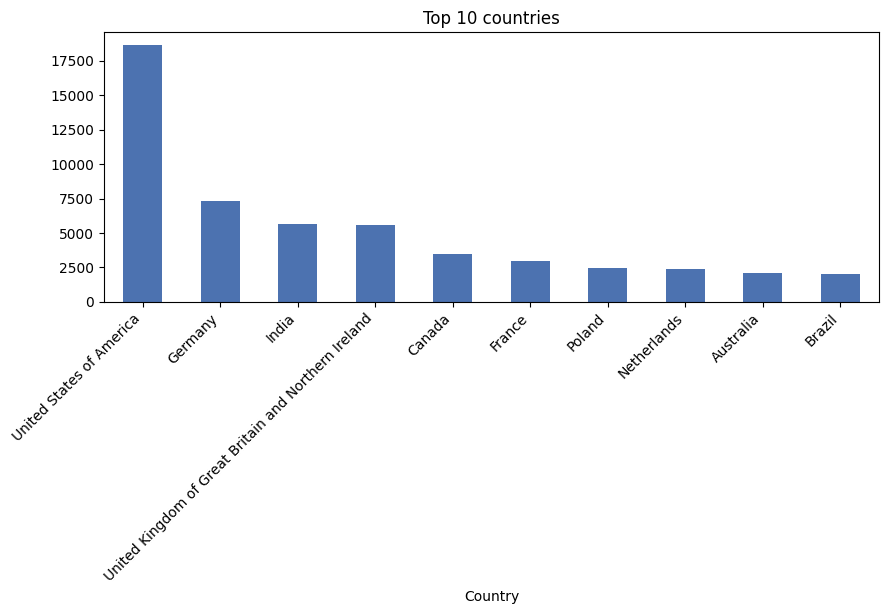

{'United States of America': 18647, 'Germany': 7328, 'India': 5625, 'United Kingdom of Great Britain and Northern Ireland': 5552, 'Canada': 3507, 'France': 2933, 'Poland': 2435, 'Netherlands': 2383, 'Australia': 2078, 'Brazil': 2042}


In [2]:
cc=df['Country'].value_counts().head(10)
fig,ax=plt.subplots(figsize=(10,3.5)); cc.plot(kind='bar',ax=ax,color='#4c72b0'); ax.set_title('Top 10 countries'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(cc.to_dict())

## 2. Most-used languages

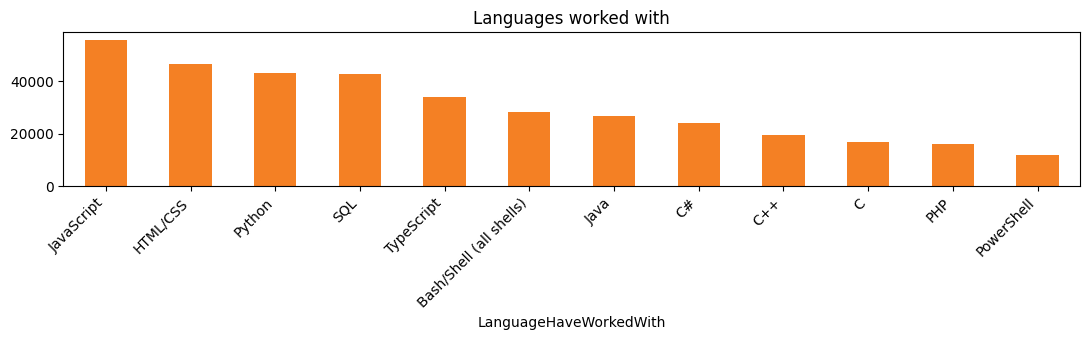

{'JavaScript': 55711, 'HTML/CSS': 46396, 'Python': 43158, 'SQL': 42623, 'TypeScript': 34041, 'Bash/Shell (all shells)': 28351}


In [3]:
langs=df['LanguageHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(12)
fig,ax=plt.subplots(figsize=(11,3.5)); langs.plot(kind='bar',ax=ax,color='#f48024'); ax.set_title('Languages worked with'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(langs.head(6).to_dict())

## 3. How developers work (remote) & education

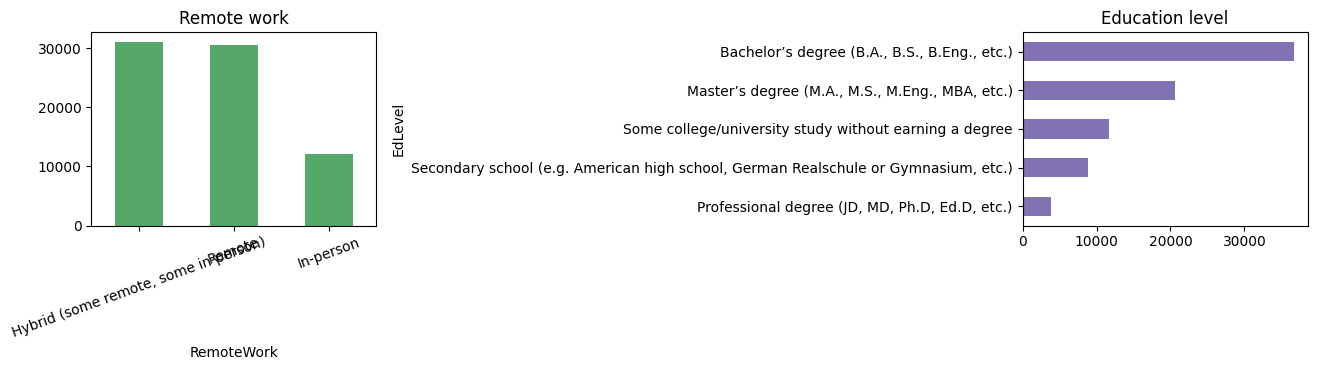

In [4]:
fig,ax=plt.subplots(1,2,figsize=(13,3.8))
df['RemoteWork'].value_counts().plot(kind='bar',ax=ax[0],color='#55a868'); ax[0].set_title('Remote work'); ax[0].tick_params(axis='x',rotation=20)
df['EdLevel'].value_counts().head(5).plot(kind='barh',ax=ax[1],color='#8172b3'); ax[1].invert_yaxis(); ax[1].set_title('Education level')
plt.tight_layout(); plt.show()

## 4. Compensation

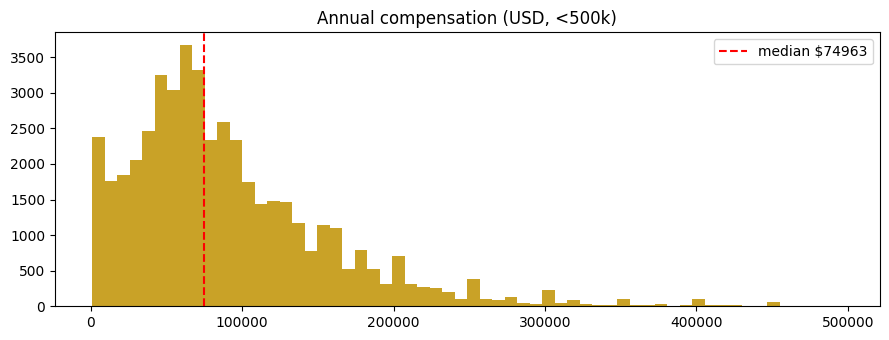

median comp: $74963


In [5]:
comp=df['ConvertedCompYearly'].dropna(); comp=comp[(comp>1000)&(comp<500000)]
fig,ax=plt.subplots(figsize=(9,3.5)); ax.hist(comp,bins=60,color='#c9a227'); ax.axvline(comp.median(),color='red',ls='--',label='median $%d'%comp.median()); ax.set_title('Annual compensation (USD, <500k)'); ax.legend(); plt.tight_layout(); plt.show()
print('median comp: $%d'%comp.median())

## 5. Key findings

- **89,184 responses**; the community skews **US-heavy** (18,647) then Germany, India, UK, Canada.
- **JavaScript is still #1** (used by 55,711), with **HTML/CSS, Python, SQL, TypeScript** close behind — the web stack dominates.
- **Hybrid + fully-remote outnumber in-person ~5:1** — remote/hybrid is now the developer norm post-2020.
- **Bachelor's is the modal education**, followed by Master's — but a meaningful minority are self-taught/no-degree.
- **Median converted annual compensation is ~\$75,000 USD** (heavily right-skewed and dominated by the large US sample).
- Caveat: SO's audience self-selects (English-speaking, engaged devs), so this describes *SO's community*, not all developers.